<a href="https://colab.research.google.com/github/Floressek/Artificial_Intelligence_lab/blob/google_collab/3_granica_decyzyjna_Szymon_Florek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Liniowa Granica Decyzyjna

### Prosta sieć neuronowa

- 2 wejścia: $x_1$, $x_2$  
- 1 warstwa ukryta z 2 neuronami  
- 1 neuron wyjściowy  
- **Brak funkcji aktywacji** w całej sieci

### Warstwa ukryta:
$$
h_1 = w_{11}x_1 + w_{12}x_2 + b_1 \\
h_2 = w_{21}x_1 + w_{22}x_2 + b_2
$$

Wybieramy proste wagi:

$$
W_1 = \begin{bmatrix}
1 & 1 \\
-1 & 1 \\
\end{bmatrix}, \quad
b_1 = \begin{bmatrix}
0 \\
0 \\
\end{bmatrix}
$$

Obliczamy więc:

$$
h_1 = x_1 + x_2 \\
h_2 = -x_1 + x_2
$$

### Warstwa wyjściowa:
$$
y = v_1 h_1 + v_2 h_2 + b
$$

Wybieramy:

$$
v = \begin{bmatrix}
1 \\
1 \\
\end{bmatrix}, \quad
b = 0
$$

Zatem końcowe wyjście to:

$$
y = h_1 + h_2 = (x_1 + x_2) + (-x_1 + x_2) = 2x_2
$$


## Granica decyzyjna

Zakładamy, że to problem **klasyfikacji binarnej**. Granica decyzyjna jest określona tam, gdzie wyjście sieci wynosi $y = 0$ (Dlaczego? Gdy nie ma funkcji aktywacji, używamy $y = 0$ jako progu decyzyjnego, ponieważ to naturalny punkt środkowy nieograniczonego zakresu wyjść — oddzielający dodatnie wyniki (klasa 1) od ujemnych (klasa 0)).

Ponieważ:
$$
y = 2x_2 = 0 \Rightarrow x_2 = 0
$$

**Granica decyzyjna:** pozioma linia przy $x_2 = 0$.


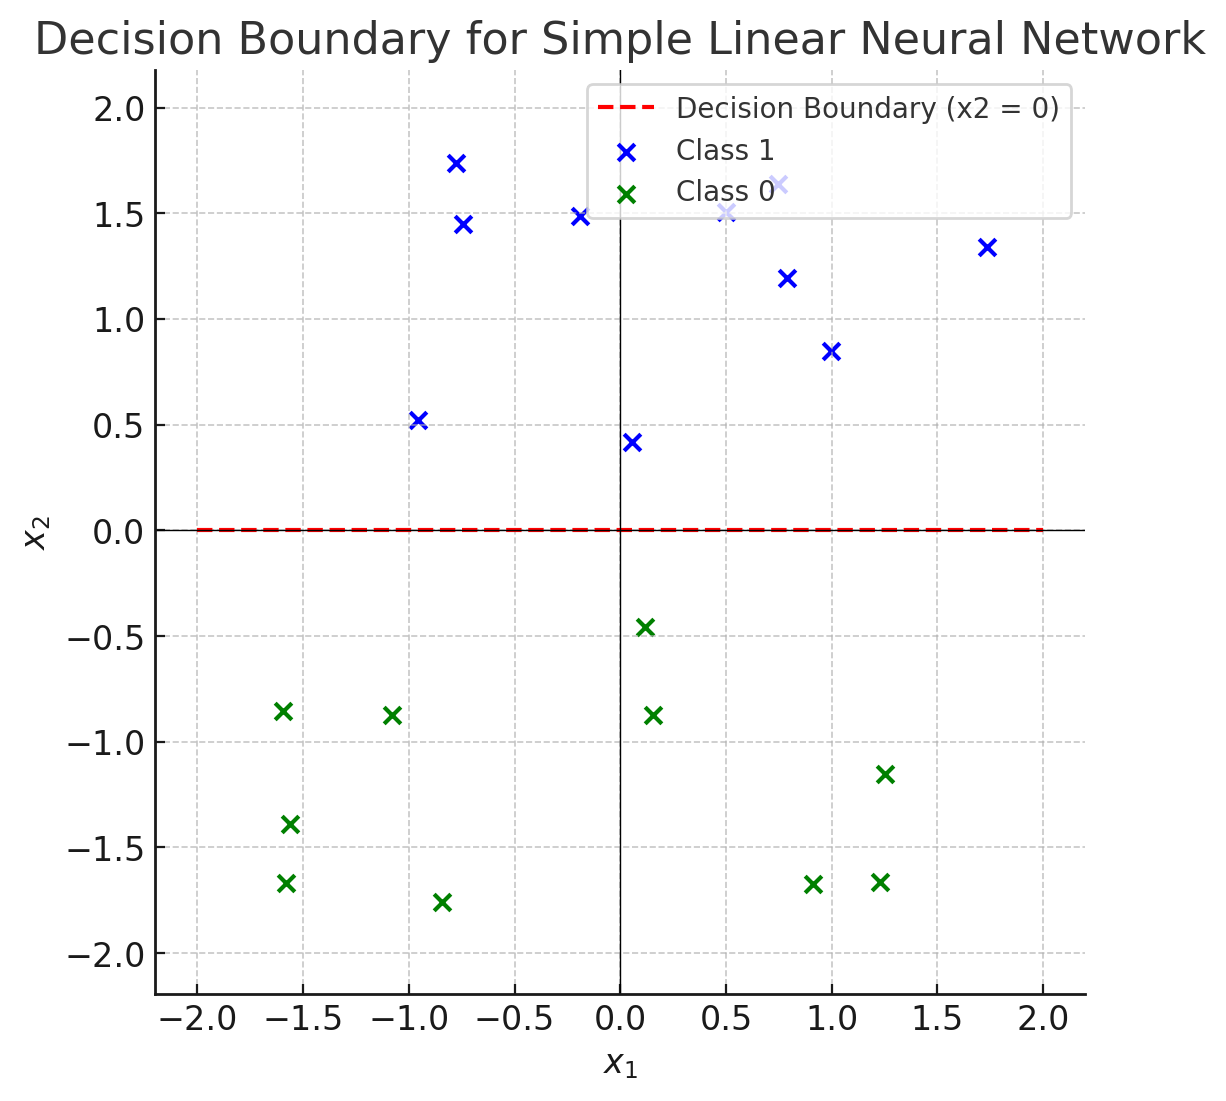

## Dwie Cechy

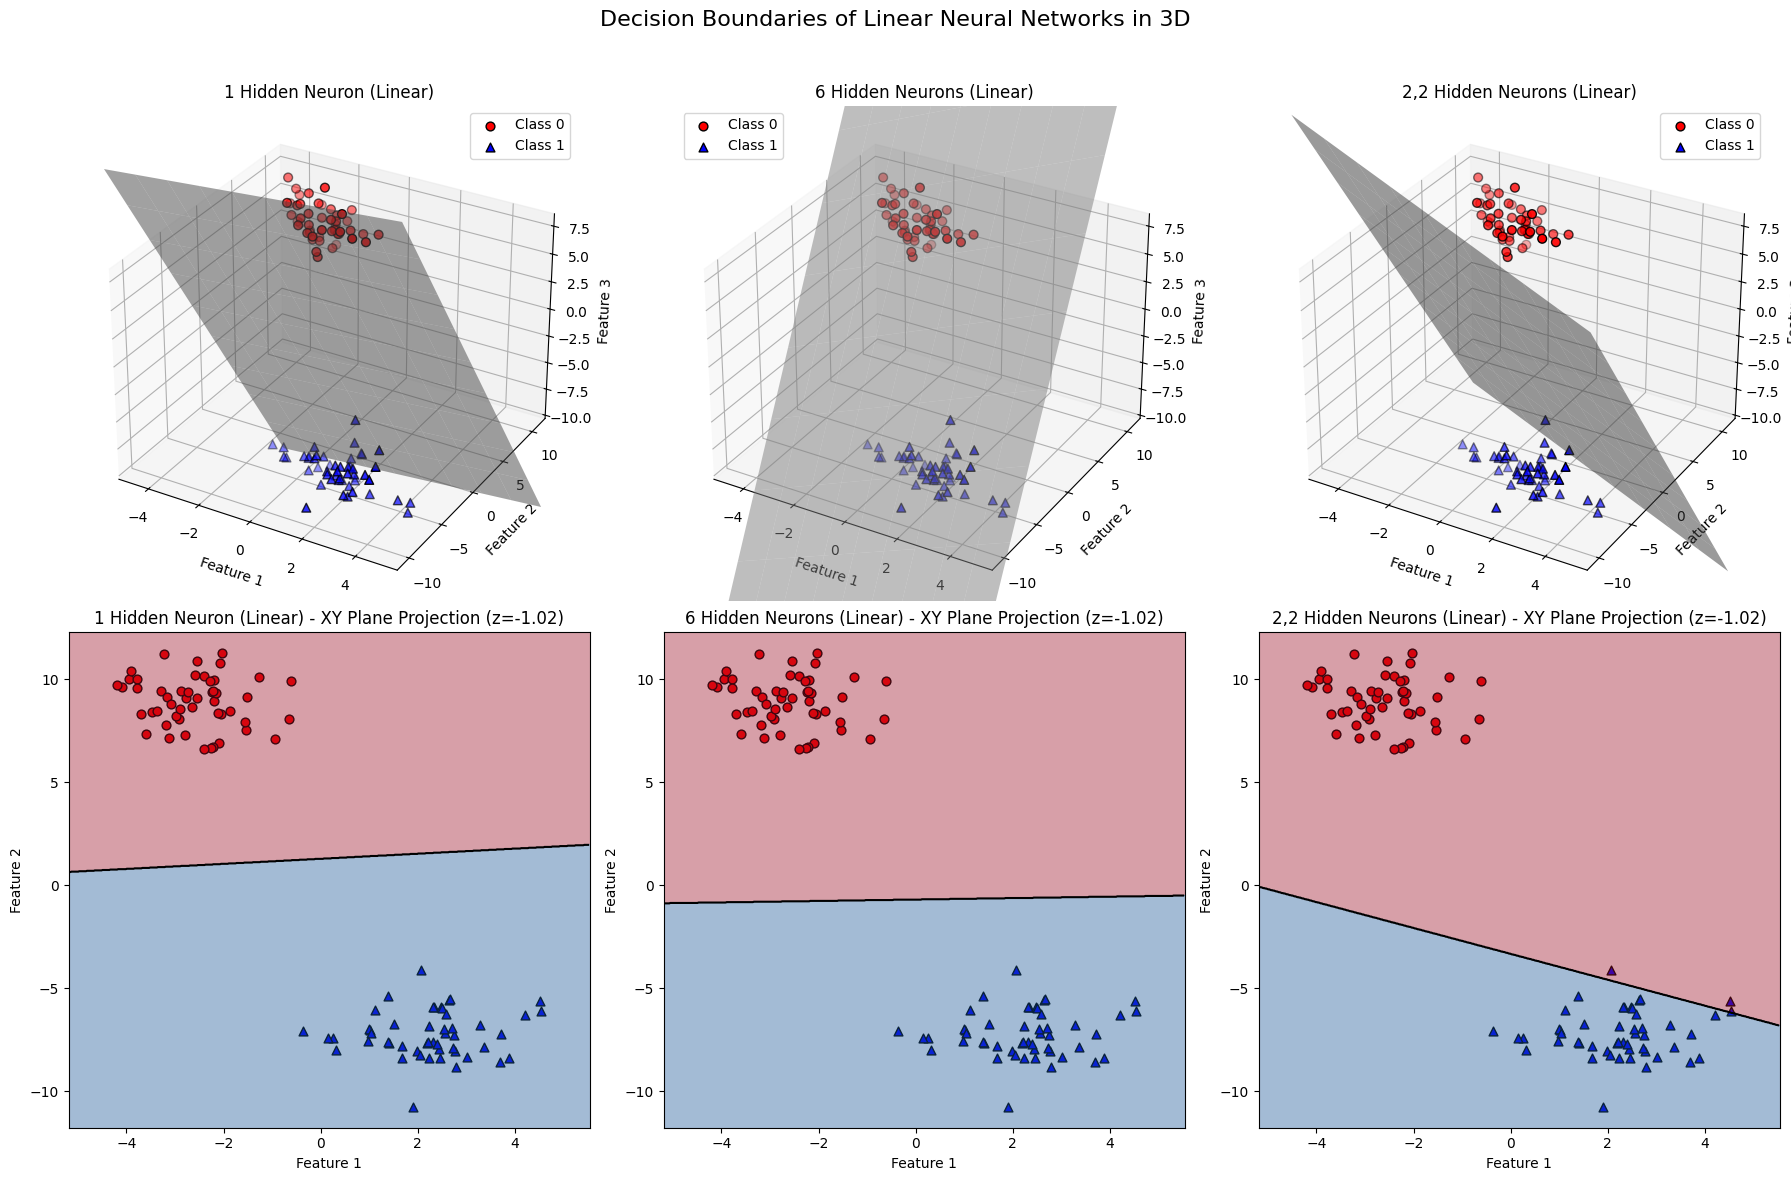


Analysis of Network Weights and Biases for Understanding Decision Boundaries:

1 Hidden Neuron (Linear):
  Input -> Hidden Layer Weights:
  [[-0.09077541]
 [ 0.73700868]
 [ 0.464105  ]]
  Hidden Layer Biases:
  [0.28565252]
  Output Layer Weights:
  [[-0.4696516]]
  Output Layer Bias:
  [0.35543163]

6 Hidden Neurons (Linear):
  Input -> Hidden Layer Weights:
  [[ 0.04001266  0.39017227  0.12712655  0.11379495 -0.0777489   0.19611218]
 [-0.06214679  0.60091914  0.79791795 -0.23091437  0.4293861   0.08939175]
 [ 0.15039916  0.6566262  -0.66024313 -0.7142882  -0.82990065  0.58484629]]
  Hidden Layer Biases:
  [ 0.41495379  0.64258566  0.74133522  0.52859052 -0.01647346  0.41642458]
  Output Layer Weights:
  [[-0.67911868]
 [ 0.21988153]
 [-0.71712669]
 [ 0.86404741]
 [ 0.08337191]
 [-0.19957786]]
  Output Layer Bias:
  [-0.39629195]

2,2 Hidden Neurons (Linear):
  Input -> Hidden Layer Weights:
  [[-0.00073011  0.3656572 ]
 [ 0.32507221  0.1965508 ]
 [-0.06775519  0.41746956]]
  Hidden 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

# --- 1. Generate Synthetic Data with 3 features ---
X, y = make_blobs(n_samples=100, centers=2, n_features=3, cluster_std=1.2, random_state=42)

# --- 2. Define Model Configurations ---
hidden_layer_configs = [(1,), (6,), (2, 2)]
titles = [
    "1 Hidden Neuron (Linear)",
    "6 Hidden Neurons (Linear)",
    "2,2 Hidden Neurons (Linear)"
]

# --- 3. Create Plots ---
fig = plt.figure(figsize=(18, 12))

# --- 4. Train Models and Plot ---
for i, (neurons, title) in enumerate(zip(hidden_layer_configs, titles)):
    # Create and Train the MLP Classifier with linear activation
    model = MLPClassifier(
        hidden_layer_sizes=neurons,
        activation='identity',  # Linear activation
        solver='adam',
        max_iter=1000,
        random_state=0
    )
    model.fit(X, y)

    # 3D Plot
    ax = fig.add_subplot(2, 3, i+1, projection='3d')

    # Plot the training points
    ax.scatter(X[y==0, 0], X[y==0, 1], X[y==0, 2], c='r', marker='o', edgecolors='k', s=40, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], X[y==1, 2], c='b', marker='^', edgecolors='k', s=40, label='Class 1')

    # Create a grid in 3D space to visualize the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    z_min, z_max = X[:, 2].min() - 1, X[:, 2].max() + 1

    # Create a meshgrid for the decision boundary
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 10),
                         np.linspace(y_min, y_max, 10))

    # For each point in the meshgrid, we need to decide which z-coordinate
    # would place it on the decision boundary (where probability = 0.5)

    # Flatten the meshgrid points
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # For a linear model, we can extract the coefficients that define the plane
    # Get the coefficients from the first layer
    coefs = model.coefs_[0][:, 0] if neurons[0] == 1 else model.coefs_[0].mean(axis=1)
    intercept = model.intercepts_[0][0] if neurons[0] == 1 else model.intercepts_[0].mean()

    # The decision boundary is defined by w1*x + w2*y + w3*z + b = 0
    # So z = -(w1*x + w2*y + b) / w3
    if abs(coefs[2]) > 1e-10:  # Check to avoid division by zero
        z_boundary = -(coefs[0] * xx + coefs[1] * yy + intercept) / coefs[2]

        # Plot the decision boundary as a surface
        surf = ax.plot_surface(xx, yy, z_boundary, alpha=0.5, color='gray')
    else:
        # If w3 is close to zero, the boundary is vertical
        print(f"Decision boundary for {title} is almost vertical (parallel to z-axis)")

    # Set plot limits and labels
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")
    ax.set_title(title)
    ax.legend()

    # 2D projection plots in the three planes
    # XY Plane
    ax = fig.add_subplot(2, 3, i+4)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='r', marker='o', edgecolors='k', s=40)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='b', marker='^', edgecolors='k', s=40)

    # Create a dense meshgrid for 2D visualization
    h = .02
    xx_dense, yy_dense = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_points_dense = np.c_[xx_dense.ravel(), yy_dense.ravel()]

    # We need to add a third feature to predict
    # For simplicity, we use the mean of the third feature
    z_mean = X[:, 2].mean()
    grid_points_dense_3d = np.column_stack([grid_points_dense, np.full(grid_points_dense.shape[0], z_mean)])

    # Predict on the grid
    Z = model.predict(grid_points_dense_3d)
    Z = Z.reshape(xx_dense.shape)

    # Plot the decision boundary
    ax.contourf(xx_dense, yy_dense, Z, alpha=0.4, cmap=plt.cm.RdBu)
    ax.contour(xx_dense, yy_dense, Z, colors=['k'], linestyles=['-'], levels=[0.5])

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(f"{title} - XY Plane Projection (z={z_mean:.2f})")

# --- 5. Show Plot ---
plt.suptitle("Decision Boundaries of Linear Neural Networks in 3D", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# --- 6. Analysis of Network Weights ---
print("\nAnalysis of Network Weights and Biases for Understanding Decision Boundaries:")
for i, (neurons, title) in enumerate(zip(hidden_layer_configs, titles)):
    print(f"\n{title}:")
    model = MLPClassifier(
        hidden_layer_sizes=neurons,
        activation='identity',
        solver='adam',
        max_iter=1000,
        random_state=0
    )
    model.fit(X, y)

    print(f"  Input -> Hidden Layer Weights:")
    print(f"  {model.coefs_[0]}")
    print(f"  Hidden Layer Biases:")
    print(f"  {model.intercepts_[0]}")

    if len(neurons) > 1:
        print(f"  Hidden -> Hidden Layer Weights:")
        print(f"  {model.coefs_[1]}")
        print(f"  Second Hidden Layer Biases:")
        print(f"  {model.intercepts_[1]}")

    print(f"  Output Layer Weights:")
    print(f"  {model.coefs_[-1]}")
    print(f"  Output Layer Bias:")
    print(f"  {model.intercepts_[-1]}")

## Ćwiczenia

1. Rozszerz kod o jedną dodatkową cechę. Zaprezentuj dane w przestrzeni. Jaką postać będzie miała granica decyzyjna w 3D?
2. Czy dodanie neuronów/warstw ukrytych przy niezmiennej liczbie cech ma wpływ na postać funkcji granicy decyzyjnej dla sieci liniowej?
3. Jaka jest rola **biasu**, a jaka **wag** w procesie wyznaczania postaci granicy decyzyjnej?

## Rozwiązania

1. **Jaka postać będzie miała granica decyzyjna w 3D?**
W przestrzeni 3D granica decyzyjna dla sieci neuronowej z liniową funkcją aktywacji ma postać płaszczyzny. Jest to bezpośrednie rozszerzenie linii prostej, którą obserwujemy w 2D. Matematycznie jest reprezentowana równaniem:
    
    ***w₁x₁ + w₂x₂ + w₃x₃ + b = 0***
    gdzie:

    w₁, w₂, w₃ to wagi przypisane do każdej z trzech cech
    b to bias (przesunięcie)
    x₁, x₂, x₃ to wartości cech

Granica ta dzieli przestrzeń 3D na dwie półprzestrzenie odpowiadające dwóm klasom.

2. **Czy dodanie neuronów/warstw ukrytych przy niezmiennej liczbie cech ma wpływ na postać funkcji granicy decyzyjnej dla sieci liniowej?**
Dla sieci z liniową funkcją aktywacji ('identity') dodanie większej liczby neuronów lub warstw ukrytych nie zmienia fundamentalnej natury granicy decyzyjnej - pozostaje ona liniowa. Wynika to z faktu, że kompozycja funkcji liniowych zawsze daje funkcję liniową.
Konkretnie:



*   Sieć z jednym neuronem w warstwie ukrytej tworzy pojedynczą płaszczyznę decyzyjną
*   Sieć z wieloma neuronami w warstwie ukrytej (np. 6 neuronów) również tworzy pojedynczą płaszczyznę, ale może ona mieć inną orientację w przestrzeni

Różnica pojawia się dopiero przy zastosowaniu nieliniowych funkcji aktywacji (np. ReLU, sigmoid), które umożliwiają tworzenie nieliniowych granic decyzyjnych.

3. **Jaka jest rola biasu, a jaka wag w procesie wyznaczania postaci granicy decyzyjnej?**
*Rola wag:*

* Wagi określają orientację (nachylenie) płaszczyzny decyzyjnej w przestrzeni
* Wartości wag wskazują na względną ważność poszczególnych cech w procesie klasyfikacji

*Rola biasu:*

* Bias określa przesunięcie płaszczyzny decyzyjnej względem początku układu współrzędnych
* Bez biasu granica decyzyjna zawsze przechodziłaby przez początek układu współrzędnych (0,0,0)


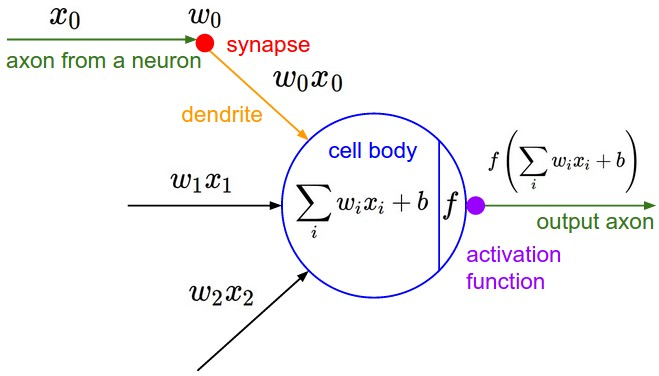

# Funkcja aktywacji

Funkcja aktywacji w sieciach neuronowych decyduje, czy neuron powinien zostać **aktywowany** (czyli przekazać swoje wyjście do następnej warstwy), wprowadzając nieliniowość. Funkcje aktywacji przyjmują ważoną sumę wejść (plus bias) i przekształcają ją, aby wygenerować wyjście neuronu.

### Dlaczego ich używać?
- **Sigmoid**: Dobra dla problemów, gdzie potrzebujesz wyjścia przypominającego prawdopodobieństwo (np. „Czy ten e-mail to spam?”). Rzadziej stosowana w ukrytych warstwach z powodu zanikających gradientów.
- **ReLU**: Preferowana w ukrytych warstwach, ponieważ jest szybka, prosta i pomaga głębokim sieciom efektywnie się uczyć, unikając problemów z gradientami.

### Wskazówki
Podczas implementacji sieci neuronowych:
- Używaj **ReLU** w ukrytych warstwach, chyba że masz konkretny powód, by tego nie robić (np. spróbuj Leaky ReLU lub GELU, jeśli ReLU działa słabo).
- Używaj **Sigmoid** w warstwie wyjściowej dla klasyfikacji binarnej, ale rozważ **Softmax** dla problemów wieloklasowych.

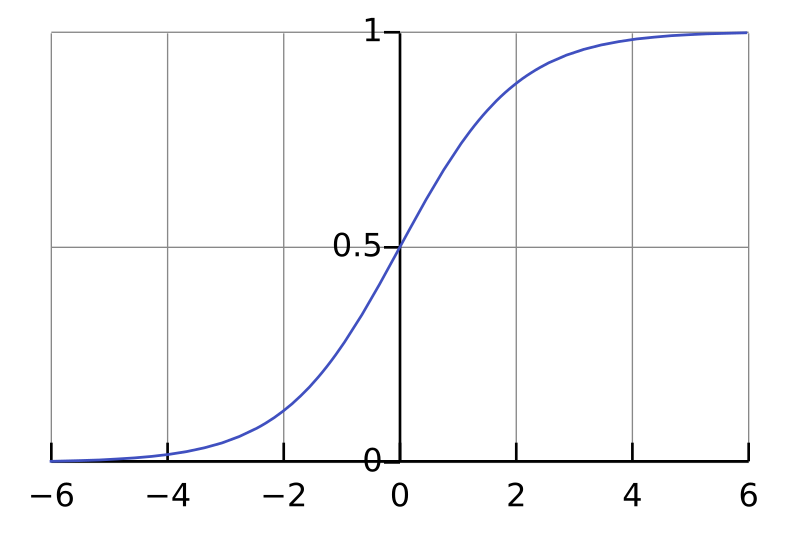

## **Funkcja Sigmoid**
- Przekształca dowolną liczbę rzeczywistą na zakres od 0 do 1.

  $
  \sigma(x) = \frac{1}{1 + e^{-x}}
  $

  gdzie $x$ to wejście (suma ważona + bias), a $e$ to podstawa logarytmu naturalnego (~2.718).
- **Jak działa**:
  - Jeśli $x$ jest dużą liczbą dodatnią, $e^{-x}$ staje się bardzo małe, więc $\sigma(x) \approx 1$.
  - Jeśli $x$ jest dużą liczbą ujemną, $e^{-x}$ staje się bardzo duże, więc $\sigma(x) \approx 0$.
  - Dla $x = 0$, $\sigma(0) = 0.5$.
- **Zastosowanie**:
  - Powszechna w klasyfikacji binarnej (np. przewidywanie „tak” lub „nie”), ponieważ wyjście można interpretować jako prawdopodobieństwo.
  - Używana w starszych sieciach neuronowych lub w warstwie wyjściowej modeli przypominających regresję logistyczną.
- **Zalety**:
  - Gładka i różniczkowalna (dobra dla optymalizacji opartej na gradientach).
  - Wyjście jest ograniczone (od 0 do 1), co jest intuicyjne dla prawdopodobieństw.
- **Wady**:
  - **Problem zanikającego gradientu**: Dla bardzo dużych lub małych $x$ gradient (pochodna) jest bliski 0, co spowalnia uczenie w głębokich sieciach.
  - Obliczeniowo kosztowna z powodu funkcji wykładniczej.
  - Wyjścia nie są wycentrowane wokół 0, co może sprawić, że uczenie jest mniej efektywne.

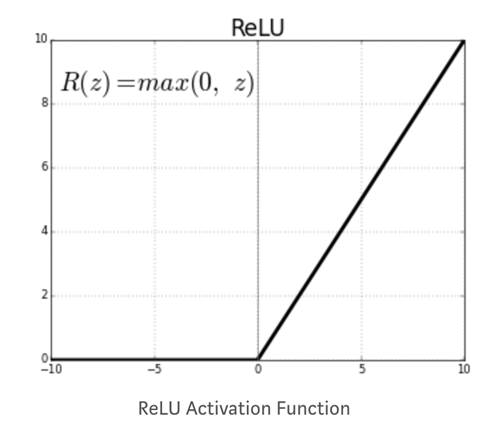

## **Funkcja ReLU** (Rectified Linear Unit)
- Zwraca wejście, jeśli jest dodatnie; w przeciwnym razie zwraca 0. To prosta funkcja „progowa”.
- $
  \text{ReLU}(x) = \max(0, x)
  $
- - Jeśli $x > 0$, zwraca $x$.
  - Jeśli $x \leq 0$, zwraca 0.
  - Na przykład, $\text{ReLU}(3) = 3$, $\text{ReLU}(-2) = 0$.
- **Zastosowanie**:
  - Szeroko stosowana w ukrytych warstwach głębokich sieci neuronowych, szczególnie w zadaniach takich jak klasyfikacja obrazów (np. w CNN) czy regresja.
  - Domyślny wybór w nowoczesnych architekturach, takich jak głębokie sieci konwolucyjne czy Transformery.
- **Zalety**:
  - **Rzadkość (sparsity)**: Ujemne wejścia dają 0, co dezaktywuje niektóre neurony, co może zwiększyć efektywność i zmniejszyć przeuczenie.
  - **Unika zanikających gradientów**: Dla dodatnich wejść gradient jest stały (1), co przyspiesza uczenie w głębokich sieciach.
  - Tanie obliczeniowo (tylko porównanie i kopiowanie).
- **Wady**:
  - **Problem martwych neuronów ReLU**: Neurony mogą „utknąć”, zwracając 0 dla wszystkich wejść, jeśli wagi spychają wejścia na ujemną stronę (brak gradientu do aktualizacji wag).
  - Nieróżniczkowalna w punkcie $x = 0$, choć w praktyce radzi się z tym przez przypisanie podgradientu (np. 0 lub 1).
  - Nieograniczone wyjście (może prowadzić do eksplozji wartości w niektórych przypadkach).

## Ćwiczenia

1. Opisz dwie wybrane funkcje aktywacji nie wymienione wyżej. Zamieść ich wykresy, wzory oraz przedstaw zbiór wartości.

## Rozwiązania

# Funkcje aktywacji: `tanh` i `Softplus`

## 1. Funkcja aktywacji: **tanh** (tangens hiperboliczny)


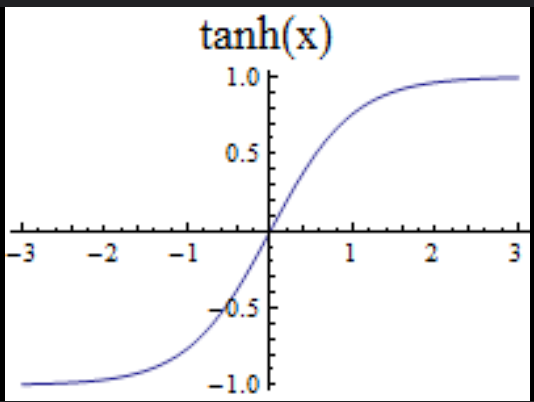



### Wzór matematyczny

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

lub alternatywnie:

$$
\tanh(x) = 2 \sigma(2x) - 1
$$

gdzie $$\sigma(x)$$ to funkcja sigmoidalna.

### Zbiór wartości funkcji `tanh`

$$
\tanh(x) \in (-1, 1)
$$

- Funkcja przyjmuje wartości od -1 do 1 (nieosiągalne skrajnie).
- Asymptotycznie zbliża się do -1 dla $$x \to -\infty$$ i do 1 dla $$x \to +\infty$$

---

### Właściwości `tanh`
- Funkcja **ciągła i różniczkowalna** w całym $$\mathbb{R}$$
- **Nieparzysta**: $$\tanh(-x) = -\tanh(x)$$
- Wartości **symetryczne wokół 0** (zero-centered).
- Przydatna w sieciach neuronowych, szczególnie w starszych RNN-ach.

---

## 2. Funkcja aktywacji: **Softplus**


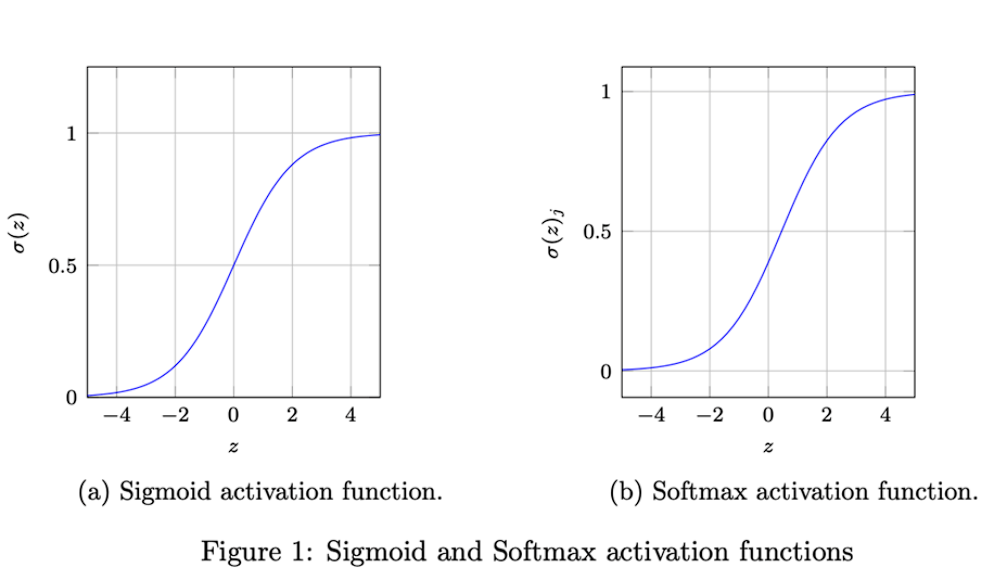



### Wzór matematyczny

$$
\text{Softplus}(x) = \ln(1 + e^x)
$$

### Zbiór wartości funkcji `Softplus`

$$
\text{Softplus}(x) \in (0, +\infty)
$$

- Przy $$x \to -\infty$$ funkcja dąży do 0.
- Przy $$x \to +\infty$$ funkcja zachowuje się jak $$x$$ (rośnie liniowo).

---

### Właściwości `Softplus`
- Funkcja **ciągła i różniczkowalna** w całym $$\mathbb{R}$$
- **Wygładzona wersja ReLU** – brak ostrego załamania w 0.
- **Nie powoduje martwych neuronów** – gradient nigdy nie jest zerowy.


# Nieliniowa granica decyzyjna

Training Sigmoid Model:
Epoch 0, Loss: 0.8108
Epoch 1000, Loss: 0.6021
Epoch 2000, Loss: 0.6017
Epoch 3000, Loss: 0.6009
Epoch 4000, Loss: 0.5985
Epoch 5000, Loss: 0.5889
Epoch 6000, Loss: 0.5551
Epoch 7000, Loss: 0.4660
Epoch 8000, Loss: 0.4150
Epoch 9000, Loss: 0.3804

Training ReLU Model:
Epoch 0, Loss: 0.9339
Epoch 1000, Loss: 0.3779
Epoch 2000, Loss: 0.1625
Epoch 3000, Loss: 0.1231
Epoch 4000, Loss: 0.1068
Epoch 5000, Loss: 0.0963
Epoch 6000, Loss: 0.0872
Epoch 7000, Loss: 0.0810
Epoch 8000, Loss: 0.0763
Epoch 9000, Loss: 0.0724


<ipython-input-10-b7b8d8239a16>:104: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx1, xx2, Z_sigmoid, levels=[0.5], colors='white', linewidths=2, linestyles='solid', label='Sigmoid Boundary')
<ipython-input-10-b7b8d8239a16>:105: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx1, xx2, Z_relu, levels=[0.5], colors='black', linewidths=2, linestyles='dashed', label='ReLU Boundary')


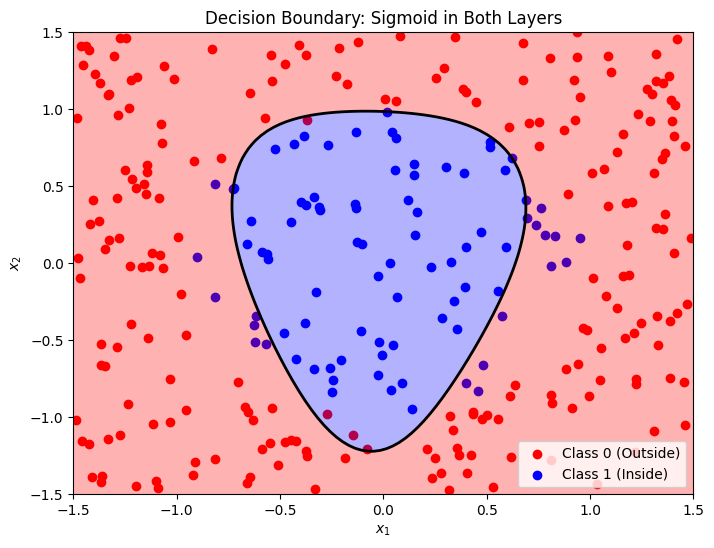

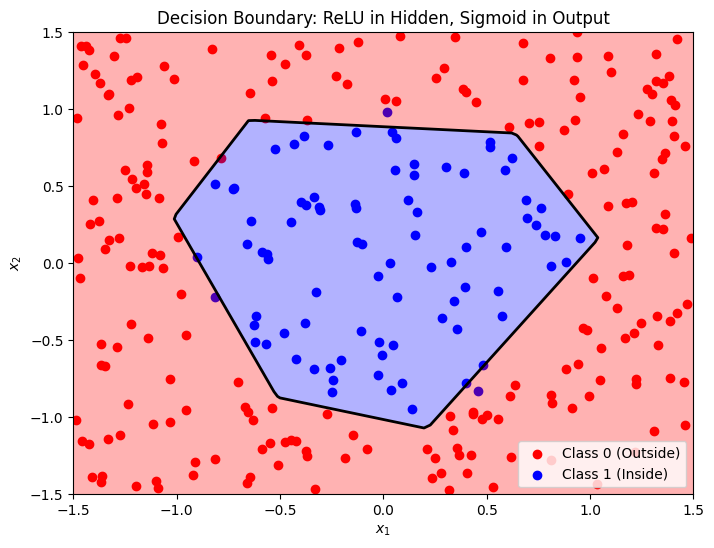

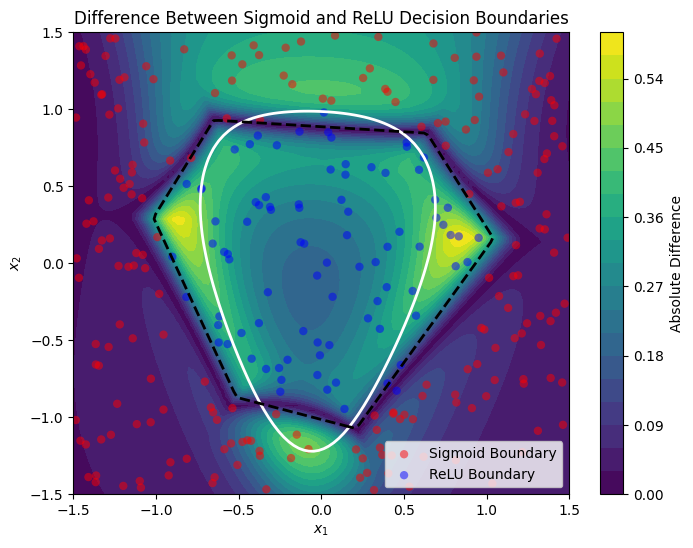

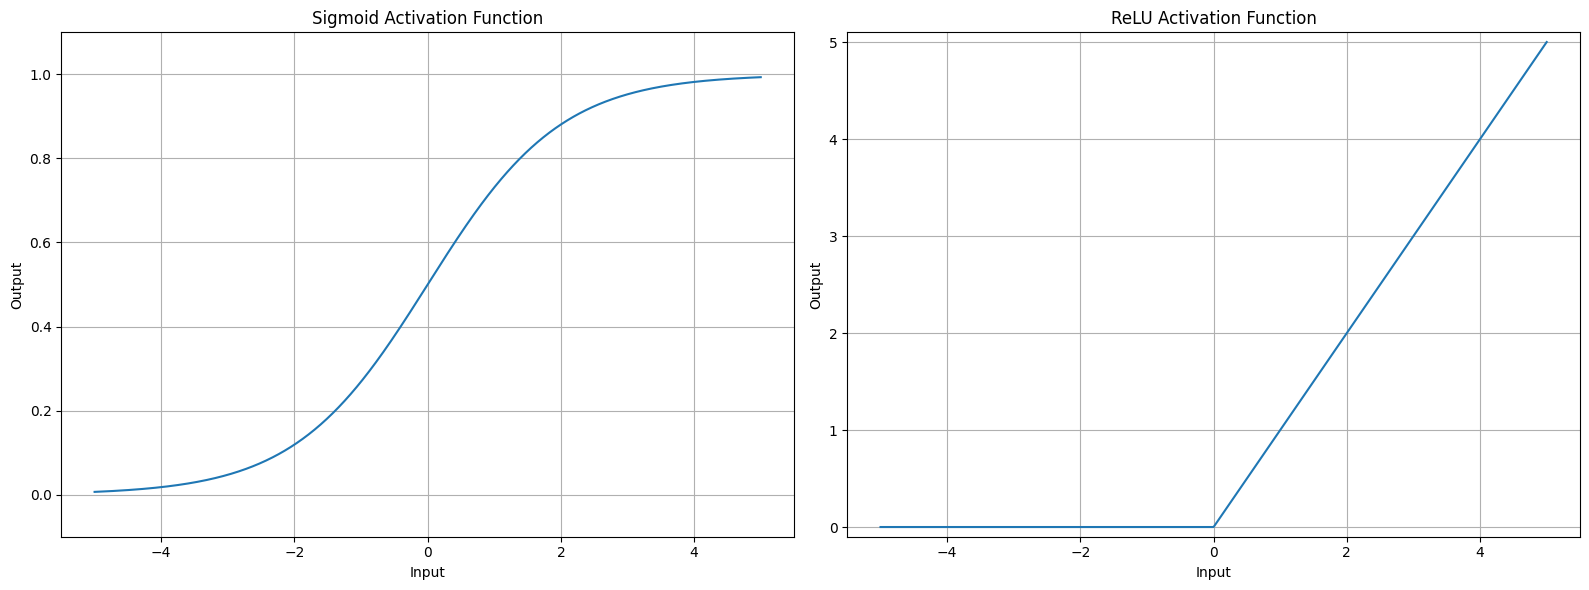


Sigmoid Hidden Layer Neuron Activations:
Neuron 0: Active: 63.0% (Min: 0.000, Max: 0.986, Mean: 0.240)
Neuron 1: Active: 55.0% (Min: 0.000, Max: 0.992, Mean: 0.237)
Neuron 2: Active: 100.0% (Min: 0.242, Max: 0.777, Mean: 0.511)
Neuron 3: Active: 81.7% (Min: 0.002, Max: 0.907, Mean: 0.296)

ReLU Hidden Layer Neuron Activations:
Neuron 0: Active: 49.0% (Min: 0.000, Max: 6.583, Mean: 1.216)
Neuron 1: Active: 44.7% (Min: 0.000, Max: 5.168, Mean: 1.110)
Neuron 2: Active: 0.0% (Min: 0.000, Max: 0.000, Mean: 0.000)
Neuron 3: Active: 42.3% (Min: 0.000, Max: 6.687, Mean: 1.172)


In [10]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Step 1: Generate the dataset
np.random.seed(42)
n_samples = 300
X = np.random.uniform(-1.5, 1.5, (n_samples, 2))  # 100 points in [-1.5, 1.5] x [-1.5, 1.5]
y = (X[:, 0]**2 + X[:, 1]**2 < 1).astype(int)     # Label: 1 if inside circle, 0 if outside

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# Step 2: Define the neural networks

# Original network with Sigmoid in both layers
class SigmoidNN(nn.Module):
    def __init__(self):
        super(SigmoidNN, self).__init__()
        self.layer1 = nn.Linear(2, 4)    # Input (2) -> Hidden (4)
        self.sigmoid = nn.Sigmoid()      # Sigmoid activation
        self.layer2 = nn.Linear(4, 1)    # Hidden (4) -> Output (1)

    def forward(self, x):
        x = self.sigmoid(self.layer1(x))  # Hidden layer with Sigmoid
        x = self.sigmoid(self.layer2(x))  # Output layer with Sigmoid
        return x

# Modified network with ReLU in hidden layer and Sigmoid in output layer
class ReLUNN(nn.Module):
    def __init__(self):
        super(ReLUNN, self).__init__()
        self.layer1 = nn.Linear(2, 4)    # Input (2) -> Hidden (4)
        self.relu = nn.ReLU()            # ReLU activation
        self.layer2 = nn.Linear(4, 1)    # Hidden (4) -> Output (1)
        self.sigmoid = nn.Sigmoid()      # Sigmoid activation for output

    def forward(self, x):
        x = self.relu(self.layer1(x))    # Hidden layer with ReLU
        x = self.sigmoid(self.layer2(x))  # Output layer with Sigmoid
        return x

# Function to train models
def train_model(model, X_tensor, y_tensor, epochs=10000):
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    for epoch in range(epochs):
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 1000 == 0:
            print(f'Epoch {epoch}, Loss: {loss.item():.4f}')

    return model

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, title):
    x1_min, x1_max = -1.5, 1.5
    x2_min, x2_max = -1.5, 1.5
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    grid_tensor = torch.FloatTensor(grid)

    with torch.no_grad():
        Z = model(grid_tensor).reshape(xx1.shape).numpy()

    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', label='Class 0 (Outside)')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', label='Class 1 (Inside)')
    plt.contourf(xx1, xx2, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['red', 'blue'])
    plt.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)  # Decision boundary
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.title(title)

    return Z

# Initialize and train both models
sigmoid_model = SigmoidNN()
relu_model = ReLUNN()

print("Training Sigmoid Model:")
sigmoid_model = train_model(sigmoid_model, X_tensor, y_tensor)
print("\nTraining ReLU Model:")
relu_model = train_model(relu_model, X_tensor, y_tensor)

# Plot decision boundaries
Z_sigmoid = plot_decision_boundary(sigmoid_model, X, y, 'Decision Boundary: Sigmoid in Both Layers')
Z_relu = plot_decision_boundary(relu_model, X, y, 'Decision Boundary: ReLU in Hidden, Sigmoid in Output')

# Plot the difference between the decision boundaries
plt.figure(figsize=(8, 6))
diff = np.abs(Z_sigmoid - Z_relu)
plt.contourf(xx1, xx2, diff, levels=20, cmap='viridis')
plt.colorbar(label='Absolute Difference')
plt.contour(xx1, xx2, Z_sigmoid, levels=[0.5], colors='white', linewidths=2, linestyles='solid', label='Sigmoid Boundary')
plt.contour(xx1, xx2, Z_relu, levels=[0.5], colors='black', linewidths=2, linestyles='dashed', label='ReLU Boundary')
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', alpha=0.5, edgecolors='none')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', alpha=0.5, edgecolors='none')
plt.legend(['Sigmoid Boundary', 'ReLU Boundary'])
plt.title('Difference Between Sigmoid and ReLU Decision Boundaries')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')

# Visualizing the activation patterns
plt.figure(figsize=(16, 6))

# Sigmoid activation pattern
plt.subplot(1, 2, 1)
x = np.linspace(-5, 5, 1000)
sigmoid = 1 / (1 + np.exp(-x))
plt.plot(x, sigmoid)
plt.grid(True)
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.ylim(-0.1, 1.1)

# ReLU activation pattern
plt.subplot(1, 2, 2)
relu = np.maximum(0, x)
plt.plot(x, relu)
plt.grid(True)
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.ylim(-0.1, 5.1)

plt.tight_layout()
plt.show()

# Check neuron activations in hidden layer
def analyze_neuron_activations(model, X_tensor, activation_func_name):
    # Get access to intermediate activations
    intermediate_output = None

    # For Sigmoid model
    if activation_func_name == 'sigmoid':
        with torch.no_grad():
            intermediate_output = model.sigmoid(model.layer1(X_tensor)).numpy()

    # For ReLU model
    elif activation_func_name == 'relu':
        with torch.no_grad():
            intermediate_output = model.relu(model.layer1(X_tensor)).numpy()

    # Calculate statistics for each neuron
    neuron_stats = []
    for i in range(intermediate_output.shape[1]):
        neuron_output = intermediate_output[:, i]
        active_count = np.sum(neuron_output > 0.01)  # Count as active if > 0.01
        zero_count = np.sum(neuron_output <= 0.01)   # Count as zero/inactive if <= 0.01
        neuron_stats.append({
            'neuron': i,
            'min': neuron_output.min(),
            'max': neuron_output.max(),
            'mean': neuron_output.mean(),
            'active_count': active_count,
            'zero_count': zero_count,
            'active_percentage': active_count / len(neuron_output) * 100
        })

    return neuron_stats

# Analyze activations
sigmoid_activations = analyze_neuron_activations(sigmoid_model, X_tensor, 'sigmoid')
relu_activations = analyze_neuron_activations(relu_model, X_tensor, 'relu')

# Print activation statistics
print("\nSigmoid Hidden Layer Neuron Activations:")
for stats in sigmoid_activations:
    print(f"Neuron {stats['neuron']}: Active: {stats['active_percentage']:.1f}% (Min: {stats['min']:.3f}, Max: {stats['max']:.3f}, Mean: {stats['mean']:.3f})")

print("\nReLU Hidden Layer Neuron Activations:")
for stats in relu_activations:
    print(f"Neuron {stats['neuron']}: Active: {stats['active_percentage']:.1f}% (Min: {stats['min']:.3f}, Max: {stats['max']:.3f}, Mean: {stats['mean']:.3f})")

## Ćwiczenia

1. Co to znaczy, że neuron jest aktywowany bądź nie? Wytłumacz na przykładzie funkcji sigmoid oraz ReLU.
2. Jaki wpływ na działanie sieci ma neuron, który zwraca `0`?
3. Zaadaptuj powyższy kod w taki sposób, aby warstwa ukryta korzystała z `nn.ReLU()`. Dlaczego w warstwie wyjściowej musi znajdować się `nn.Sigmoid()`?
Zaprezentuj powstałą granicę decyzyjną i porównaj ją z granicą uzyskaną jedynie przy pomocy sigmoid'a.

## Rozwiązania

# 1. Co to znaczy, że neuron jest aktywowany albo nie?

Neuron w sieci neuronowej jest **aktywowany**, kiedy jego wyjście jest **większe od zera** lub **znacząco różne od zera**.  
Neuron jest **nieaktywny**, jeśli jego wyjście wynosi **0** lub jest **bliskie zeru**.

Neuron działa jak przekaźnik:  
- Jeśli jest aktywowany → przekazuje informacje dalej.
- Jeśli jest nieaktywny → **nic nie przekazuje** (nie wpływa na kolejne warstwy).

---

# Przykład: Funkcja **sigmoid**

Wzór funkcji sigmoidalnej:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Właściwości funkcji sigmoid:
- Dla $$( x \to -\infty )$$ wyjście dąży do ( 0 ).
- Dla $$( x \to +\infty )$$ wyjście dąży do ( 1 ).
- Dla $$( x = 0 )$$ wyjście wynosi dokładnie ( 0.5 ).

**Wnioski dla neuronu z funkcją sigmoid:**
- Nigdy nie zwraca dokładnie ( 0 ), ale przy bardzo dużych wartościach ujemnych aktywacja jest bardzo bliska zera.
- Neuron przy bardzo niskiej aktywacji **praktycznie przestaje wpływać** na dalsze obliczenia.

---

# Przykład: Funkcja **ReLU**

Wzór funkcji ReLU:

$$
\text{ReLU}(x) = \max(0, x)
$$

Właściwości funkcji ReLU:
- Jeśli $$( x \leq 0 )$$ to $$( \text{ReLU}(x) = 0 )$$
- Jeśli $$( x > 0 )$$ to $$( \text{ReLU}(x) = x )$$

**Wnioski dla neuronu z funkcją ReLU:**
- Neuron jest **nieaktywny** przy wejściach ujemnych lub zerowych — jego wyjście wynosi wtedy dokładnie ( 0 ).
- Neuron jest **aktywny**, gdy wejście jest dodatnie — przekazuje wartość dalej.

---

# 2. Co się dzieje, gdy neuron zwraca ( 0 )?

Jeśli neuron zwraca ( 0 ), oznacza to:

- **Brak wpływu na kolejną warstwę:** jego wyjście nie wnosi nic do sumowania z wagami następnych neuronów.
- **Brak propagacji gradientu wstecz:** w funkcji ReLU, dla wejścia $$( x \leq 0 )$$, pochodna wynosi ( 0 ), więc nie następuje aktualizacja wag połączonych z tym neuronem.
- **Potencjalny problem martwych neuronów:** jeśli neuron zawsze zwraca ( 0 ), może przestać uczestniczyć w procesie uczenia i pozostanie "martwy".


# Najważniejsze informacje

- **Aktywacja neuronu** oznacza, że jego wyjście jest znaczące i wpływa na kolejne obliczenia w sieci.
- **Neuron zwracający 0** jest nieaktywny i **nie wpływa** na dalsze warstwy.
- **W ReLU:** zbyt wiele martwych neuronów może **utrudnić uczenie** i **zmniejszyć zdolności sieci**.

---

# 3. Adaptacja kodu: zmiana aktywacji na `nn.ReLU()` w warstwie ukrytej

Kod został zmodyfikowany w taki sposób, aby:
- Warstwa ukryta korzystała z funkcji aktywacji **ReLU** (`nn.ReLU()`),
- Warstwa wyjściowa nadal wykorzystywała funkcję aktywacji **sigmoid** (`nn.Sigmoid()`).

---

# Dlaczego w warstwie wyjściowej musi być `nn.Sigmoid()`?

W warstwie wyjściowej stosujemy funkcję **sigmoid**, ponieważ:
- Sigmoid zwraca **wartości w przedziale (0, 1)**,
- Dzięki temu wynik można **interpretować jako prawdopodobieństwo** przynależności do jednej z klas,
- W zadaniach **klasyfikacji binarnej** (2 klasy: np. "tak" albo "nie") potrzebujemy właśnie takiego rozkładu wyjścia.

Jeśli używalibyśmy np. ReLU w warstwie wyjściowej:
- Otrzymywalibyśmy wartości od ( 0 ) wzwyż do $$( +\infty )$$
- Nie moglibyśmy ich bezpośrednio interpretować jako prawdopodobieństwa,
- Utrudniłoby to proces uczenia (strata np. `BCELoss` zakłada, że wyjścia to prawdopodobieństwa).

**Wniosek:**  
Warstwa wyjściowa musi używać **sigmoid**, aby model mógł poprawnie rozróżniać klasy i aby wartości były zgodne z oczekiwaniami funkcji straty.

---

# Granica decyzyjna po zastosowaniu `ReLU` w warstwie ukrytej

Po zamianie aktywacji warstwy ukrytej na **ReLU**, granica decyzyjna modelu:

- Staje się **bardziej kanciasta** (fragmenty prostoliniowe),
- Jest **mniej gładka** niż w przypadku wyłącznie funkcji sigmoidalnych,
- Bardziej przypomina **segmenty** — sieć buduje przybliżenia funkcji za pomocą prostych odcinków.

**Dlaczego?**  
- Funkcja ReLU jest **częściowo liniowa** (dla ( x > 0 ) zachowuje się jak ( x )),
- Wprowadza w modelu fragmenty z nagłymi zmianami (brak płynnego przejścia jak w sigmoidzie),
- Dlatego granica decyzyjna oparta o ReLU jest "łamana" — ale nadal może poprawnie oddzielać klasy, zwłaszcza w prostych problemach.


